# Modelling the Forst


## Setup

In [11]:
# Magic Codes 
%load_ext autoreload
%autoreload 2

# IMPORTS
from us_used_vehicle_resales.features import engineer_features
from us_used_vehicle_resales.cleaning import clean_data
import us_used_vehicle_resales as wg  
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier # <-- HIER FEHLTE ER
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from us_used_vehicle_resales.config_features_catalog import features_catalog
from us_used_vehicle_resales.config_models_catalog import models_catalog
from sklearn.preprocessing import FunctionTransformer
from us_used_vehicle_resales import models
import numpy as np
import pandas as pd
import warnings
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score


from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, recall_score, precision_score, accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:

# SETTINGS
#warnings.filterwarnings("ignore", category=FutureWarning)
#warnings.filterwarnings("ignore", category=UserWarning)

# Global Notebook Style

# Global Pandas Options
pd.options.display.float_format = '{:.4f}'.format
pd.set_option('display.memory_usage', 'deep')

# CONSTANTS
TARGET = 'IsBadBuy'
tracker = wg.ModelTracker(csv_path='../data/04_models/model_results_tracking.csv')

# LOADING DATA
wg.print_header('Modelling Started')
X_train_all = pd.read_parquet('../data/03_processed/X_train_final.parquet')
y_train_all = pd.read_parquet('../data/03_processed/y_train.parquet').iloc[:, 0]
print(f"🚀 Daten erfolgreich geladen.")
print(f"Features: {X_train_all.shape[0]} Zeilen | {X_train_all.shape[1]} Spalten")
print(f"Target:   '{y_train_all.name}' (BadBuy-Rate: {y_train_all.mean():.2%})")
wg.print_footer()


# VALIDATION SPLIT
X_train, X_val, y_train, y_val = train_test_split(
    X_train_all, y_train_all, test_size=0.2, random_state=42, stratify=y_train_all
)
wg.print_header('Validation Split')
print(f"🚀 Daten erfolgreich gesplittet.")
print(f"Train: {X_train.shape[0]} | Validation: {X_val.shape[0]}")
wg.print_footer()





~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
MODELLING STARTED
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
🚀 Daten erfolgreich geladen.
Features: 52496 Zeilen | 41 Spalten
Target:   'IsBadBuy' (BadBuy-Rate: 12.35%)
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~





~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
VALIDATION SPLIT
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
🚀 Daten erfolgreich gesplittet.
Train: 41996 | Validation: 10500
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~




# Ranking

In [52]:
# Hol dir alle Ergebnisse als DataFrame
df_results = tracker.get_results()
top_models = df_results.sort_values(by='F1-Score', ascending=False).head(33)
display(top_models)


,Run_ID,Timestamp,Model,Features Name,Features Count,F1-Score,Recall,Precision,ROC-AUC,Description,Model_File,Is_Best
451,451,2026-04-02 07:38:03,random_forest_all_in,NaN,NaN,0.4145,0.3346,0.5445,0.7692,"Random Forest (saubere Pipeline, auto feature ...",export/451_random_forest_all_in.joblib,True
454,454,2026-04-02 07:50:37,random_forest_all_in,NaN,NaN,0.4039,0.3007,0.6151,0.7704,"Random Forest (saubere Pipeline, auto feature ...",export/454_random_forest_all_in.joblib,False
455,455,2026-04-02 07:51:54,random_forest_all_in,NaN,NaN,0.4039,0.3007,0.6151,0.7704,"Random Forest (saubere Pipeline, auto feature ...",export/455_random_forest_all_in.joblib,False
433,433,2026-04-01 21:53:51,reconstructed_402_lasso_thresh_0.66,NaN,NaN,0.4014,0.3863,0.4178,0.0000,NaN,export/433_reconstructed_402_lasso_thresh_0.66...,True
457,457,2026-04-02 07:57:49,random_forest_all_in,NaN,NaN,0.3900,0.5189,0.3124,0.7686,"Random Forest (saubere Pipeline, auto feature ...",export/457_random_forest_all_in.joblib,False
456,456,2026-04-02 07:52:59,random_forest_all_in,NaN,NaN,0.3879,0.5127,0.3119,0.7677,"Random Forest (saubere Pipeline, auto feature ...",export/456_random_forest_all_in.joblib,False
429,429,2026-04-01 20:59:59,logreg_lasso_grid_best,NaN,NaN,0.3814,0.6284,0.2738,0.0000,"🏆 Gewinner: {'model__C': 0.1, 'model__solver':...",export/429_logreg_lasso_grid_best.joblib,True
431,431,2026-04-01 21:36:03,logreg_lasso_grid_best,NaN,NaN,0.3814,0.6284,0.2738,0.0000,"🏆 Gewinner: {'model__C': 0.1, 'model__max_iter...",export/431_logreg_lasso_grid_best.joblib,False
402,402,2026-04-01 11:16:09,log_reg_lasso_all_in_with_noise,NaN,NaN,0.3801,0.6245,0.2732,0.0000,Auto-Run: log_reg_lasso mit all_in_with_noise ...,export/402_log_reg_lasso_all_in_with_noise.joblib,True
406,406,2026-04-01 11:18:09,hist_boost_aggressive_all_in_with_noise,NaN,NaN,0.3756,0.6130,0.2708,0.0000,Auto-Run: hist_boost_aggressive mit all_in_wit...,export/406_hist_boost_aggressive_all_in_with_n...,False


# Next Try

🔢 Numerische Features: 19
🔤 Kategorische Features: 21

🌲 Trainiere Random Forest mit 41 Features...
💾 Modell-Datei erstellt: ../data/04_models/export/436_random_forest_all_in.joblib
ID 436: F1=0.3722 -> ✅ ÜBER 0.30 & GESPEICHERT

🧐 Inspektion von Run 436...

════════════════════════════════════════════════════════════
🔍 ANALYSE RUN_ID: 436 | Name: random_forest_all_in
════════════════════════════════════════════════════════════
⚙️  MODELL-EINSTELLUNGEN:
   • Typ:          RandomForestClassifier
   • Penalty:      N/A
   • Solver:       N/A
   • C (Regul.):   N/A
   • Class Weight: balanced
   • Max Iter:     N/A
   • Features:     (Konnte Namen nicht auslesen)
------------------------------------------------------------
📊 PERFORMANCE REPORT:
              precision    recall  f1-score   support

    Good (0)       0.93      0.76      0.84      9203
     Bad (1)       0.27      0.62      0.37      1297

    accuracy                           0.74     10500
   macro avg       0.60      0

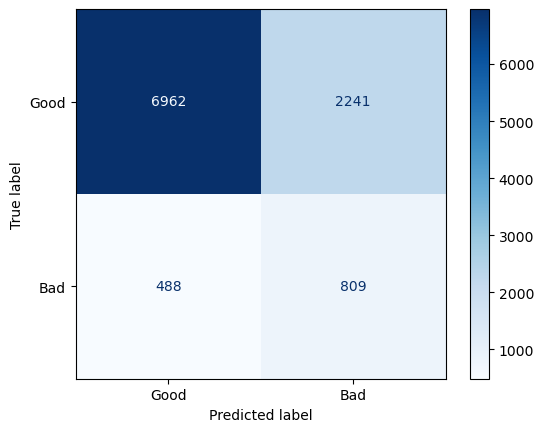

In [16]:
# ================================
# 📦 Imports
# ================================
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ================================
# 🧾 Feature-Liste
# ================================
features_all_in = [
    'PurchDate', 'Auction', 'VehYear', 'VehicleAge', 'Make', 'Model',
    'Trim', 'SubModel', 'Color', 'Transmission', 'WheelTypeID', 'WheelType',
    'VehOdo', 'Nationality', 'Size', 'TopThreeAmericanName',
    'MMRAcquisitionAuctionAveragePrice', 'MMRAcquisitionAuctionCleanPrice',
    'MMRAcquisitionRetailAveragePrice', 'MMRAcquisitonRetailCleanPrice',  # ⚠️ prüfen!
    'MMRCurrentAuctionAveragePrice', 'MMRCurrentAuctionCleanPrice',
    'MMRCurrentRetailAveragePrice', 'MMRCurrentRetailCleanPrice',
    'PRIMEUNIT', 'AUCGUART', 'BYRNO', 'VNZIP1', 'VNST', 'VehBCost',
    'IsOnlineSale', 'WarrantyCost',
    'feat_price_ratio', 'feat_price_diff', 'feat_market_trend',
    'feat_miles_per_year', 'feat_warranty_ratio', 'feat_age_group',
    'feat_odo_risk', 'feat_price_cat', 'feat_warranty_peak'
]

# ================================
# 🏗️ Pipeline Builder (BEST PRACTICE)
# ================================
def build_rf_pipeline(X, feature_list):
    """
    Baut eine robuste sklearn Pipeline:
    - erkennt automatisch numerische/kategorische Features
    - ignoriert fehlende Spalten sauber
    """

    # Nur Features verwenden, die wirklich existieren
    available_features = [col for col in feature_list if col in X.columns]

    if len(available_features) == 0:
        raise ValueError("❌ Keine gültigen Features im DataFrame gefunden!")

    # Feature-Typen bestimmen
    numeric_features = X[available_features].select_dtypes(
        include=['int64', 'float64']
    ).columns.tolist()

    categorical_features = X[available_features].select_dtypes(
        include=['object', 'category', 'bool']
    ).columns.tolist()

    print(f"🔢 Numerische Features: {len(numeric_features)}")
    print(f"🔤 Kategorische Features: {len(categorical_features)}")

    # Transformer
    numeric_transformer = StandardScaler()

    categorical_transformer = OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    )

    # Preprocessor
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ],
        remainder='drop'
    )

    # Modell
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    # Pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    return pipeline, available_features


# ================================
# 🚀 Pipeline erstellen
# ================================
rf_pipeline, valid_features = build_rf_pipeline(X_train, features_all_in)

# ================================
# 🏋️ Training
# ================================
print(f"\n🌲 Trainiere Random Forest mit {len(valid_features)} Features...")
rf_pipeline.fit(X_train[valid_features], y_train)

# ================================
# 🔮 Vorhersagen
# ================================
y_pred_rf = rf_pipeline.predict(X_val[valid_features])
y_proba_rf = rf_pipeline.predict_proba(X_val[valid_features])[:, 1]

# ================================
# 📊 Tracking
# ================================
run_id = tracker.add_entry(
    model_name="random_forest_all_in",
    model_obj=rf_pipeline,
    features_name="All-In Clean Pipeline",
    features_list=valid_features,
    y_true=y_val,
    y_pred=y_pred_rf,
    y_proba=y_proba_rf,
    description="Random Forest (saubere Pipeline, auto feature detection)"
)

# ================================
# 🔍 Analyse
# ================================
print(f"\n🧐 Inspektion von Run {run_id}...")
models.inspect_run_full(
    run_id,
    X_val[valid_features],
    y_val,
    tracker
)

* Recall (BadBuy) = 0.62 → gut (du findest viele Montagsautos)
* Precision (BadBuy) = 0.27 → niedrig (du alarmierst oft fälschlich)
* F1 = 0.37 → solide baseline

In [18]:
# ================================
# 📦 Imports
# ================================
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ================================
# 🧾 Feature-Liste
# ================================
features = features_catalog['champion_v1']

# ================================
# 🏗️ Pipeline Builder (BEST PRACTICE)
# ================================
def build_rf_pipeline(X, feature_list):
    """
    Baut eine robuste sklearn Pipeline:
    - erkennt automatisch numerische/kategorische Features
    - ignoriert fehlende Spalten sauber
    """

    # Nur Features verwenden, die wirklich existieren
    available_features = feature_list


    # Feature-Typen bestimmen
    numeric_features = X[available_features].select_dtypes(
        include=['int64', 'float64']
    ).columns.tolist()

    categorical_features = X[available_features].select_dtypes(
        include=['object', 'category', 'bool']
    ).columns.tolist()

    print(f"🔢 Numerische Features: {len(numeric_features)}")
    print(f"🔤 Kategorische Features: {len(categorical_features)}")

    # Transformer
    numeric_transformer = StandardScaler()

    categorical_transformer = OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    )

    # Preprocessor
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ],
        remainder='drop'
    )

    # Modell
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    # Pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    return pipeline, available_features


# ================================
# 🚀 Pipeline erstellen
# ================================
rf_pipeline, valid_features = build_rf_pipeline(X_train, features)

# ================================
# 🏋️ Training
# ================================
print(f"\n🌲 Trainiere Random Forest mit {len(valid_features)} Features...")
rf_pipeline.fit(X_train[valid_features], y_train)

# ================================
# 🔮 Vorhersagen
# ================================
y_pred_rf = rf_pipeline.predict(X_val[valid_features])
y_proba_rf = rf_pipeline.predict_proba(X_val[valid_features])[:, 1]

# ================================
# 📊 Tracking
# ================================
run_id = tracker.add_entry(
    model_name="random_forest_all_in",
    model_obj=rf_pipeline,
    features_name="Champion Clean Pipeline",
    features_list=valid_features,
    y_true=y_val,
    y_pred=y_pred_rf,
    y_proba=y_proba_rf,
    description="Random Forest (saubere Pipeline, auto feature detection)"
)

# ================================
# 🔍 Analyse
# ================================
print(f"\n🧐 Inspektion von Run {run_id}...")
models.inspect_run_full(
    run_id,
    X_val[valid_features],
    y_val,
    tracker
)

🔢 Numerische Features: 4
🔤 Kategorische Features: 6

🌲 Trainiere Random Forest mit 10 Features...
ID 438: F1=0.2955 -> 🔈 Nur CSV (F1 zu niedrig)

🧐 Inspektion von Run 438...
❌ Datei nicht gefunden: ../data/04_models/No


In [ ]:
# ZU langsam

In [19]:
# ================================
# 📦 Imports
# ================================
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import RandomizedSearchCV

# ================================
# 🧾 Feature-Liste
# ================================
features = features_catalog['champion_v1']

# ================================
# 🏗️ Pipeline Builder
# ================================
def build_rf_pipeline(X, feature_list):

    available_features = [col for col in feature_list if col in X.columns]

    numeric_features = X[available_features].select_dtypes(
        include=['int64', 'float64']
    ).columns.tolist()

    categorical_features = X[available_features].select_dtypes(
        include=['object', 'category', 'bool']
    ).columns.tolist()

    print(f"🔢 Numerische Features: {len(numeric_features)}")
    print(f"🔤 Kategorische Features: {len(categorical_features)}")

    numeric_transformer = StandardScaler()

    categorical_transformer = OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ],
        remainder='drop'
    )

    model = RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    )

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    return pipeline, available_features


# ================================
# 🚀 Pipeline erstellen
# ================================
rf_pipeline, valid_features = build_rf_pipeline(X_train, features)

# ================================
# 🎲 Random Search Setup
# ================================
param_dist = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, None],
    'model__min_samples_leaf': [5, 10],
    'model__max_features': ['sqrt'],
    'model__class_weight': [
        'balanced',
        {0:1, 1:3}
    ]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,
    n_iter=10,        # 🔥 statt 25
    scoring='recall',
    cv=2,             # 🔥 statt 3
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# ================================
# 🏋️ Training (inkl. Search)
# ================================
print("\n🎲 Starte Random Search...")
random_search.fit(X_train[valid_features], y_train)

print(f"\n🏆 Best Params: {random_search.best_params_}")

best_pipeline = random_search.best_estimator_

# ================================
# 🔮 Vorhersagen
# ================================
y_proba_rf = best_pipeline.predict_proba(X_val[valid_features])[:, 1]

# 👉 Optional: aggressiver Threshold für mehr Recall
threshold = 0.3
y_pred_rf = (y_proba_rf >= threshold).astype(int)

# ================================
# 📊 Tracking
# ================================
run_id = tracker.add_entry(
    model_name="random_forest_random_search",
    model_obj=best_pipeline,
    features_name="Champion + RandomSearch",
    features_list=valid_features,
    y_true=y_val,
    y_pred=y_pred_rf,
    y_proba=y_proba_rf,
    description=f"RandomSearch RF | BestParams={random_search.best_params_} | threshold={threshold}"
)

# ================================
# 🔍 Analyse
# ================================
print(f"\n🧐 Inspektion von Run {run_id}...")
models.inspect_run_full(
    run_id,
    X_val[valid_features],
    y_val,
    tracker
)

ERROR! Session/line number was not unique in database. History logging moved to new session 718
🔢 Numerische Features: 4
🔤 Kategorische Features: 6

🎲 Starte Random Search...
Fitting 2 folds for each of 10 candidates, totalling 20 fits


KeyboardInterrupt: 

✅ Setup bereit: 19 Numerisch, 21 Kategorisch
🌲 Trainiere Random Forest...
💾 Modell-Datei erstellt: ../data/04_models/export/440_random_forest_all_in_v1.joblib
ID 440: F1=0.3525 -> ✅ ÜBER 0.30 & GESPEICHERT

🚀 Modell unter ID 440 gespeichert. Starte Analyse...

════════════════════════════════════════════════════════════
🔍 ANALYSE RUN_ID: 440 | Name: random_forest_all_in_v1
════════════════════════════════════════════════════════════
⚙️  MODELL-EINSTELLUNGEN:
   • Typ:          RandomForestClassifier
   • Penalty:      N/A
   • Solver:       N/A
   • C (Regul.):   N/A
   • Class Weight: balanced
   • Max Iter:     N/A
   • Features:     41 Spalten
------------------------------------------------------------
📊 PERFORMANCE REPORT:
              precision    recall  f1-score   support

    Good (0)       0.93      0.76      0.84      9203
     Bad (1)       0.27      0.62      0.37      1297

    accuracy                           0.74     10500
   macro avg       0.60      0.69      0.60 

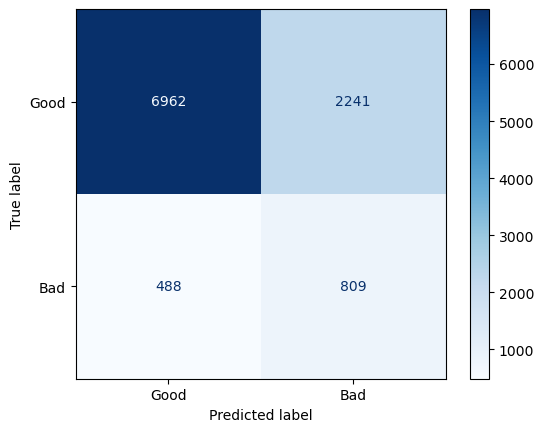

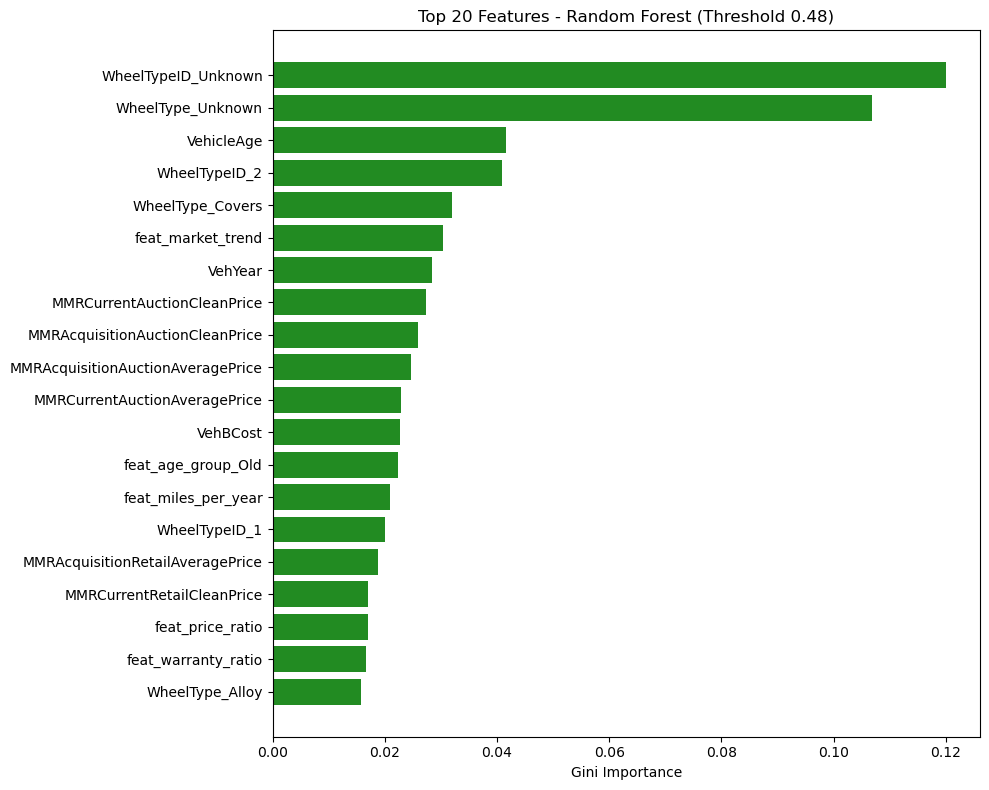

In [22]:
# ==============================================================================
# 🧾 1. FEATURE-LISTE (Ganz oben)
# ==============================================================================
# Hier definierst du, welche Spalten das Modell sehen darf
features_all_in = [
    'PurchDate', 'Auction', 'VehYear', 'VehicleAge', 'Make', 'Model',
    'Trim', 'SubModel', 'Color', 'Transmission', 'WheelTypeID', 'WheelType',
    'VehOdo', 'Nationality', 'Size', 'TopThreeAmericanName',
    'MMRAcquisitionAuctionAveragePrice', 'MMRAcquisitionAuctionCleanPrice',
    'MMRAcquisitionRetailAveragePrice', 'MMRAcquisitonRetailCleanPrice',
    'MMRCurrentAuctionAveragePrice', 'MMRCurrentAuctionCleanPrice',
    'MMRCurrentRetailAveragePrice', 'MMRCurrentRetailCleanPrice',
    'PRIMEUNIT', 'AUCGUART', 'BYRNO', 'VNZIP1', 'VNST', 'VehBCost',
    'IsOnlineSale', 'WarrantyCost', 'feat_price_ratio', 'feat_price_diff',
    'feat_market_trend', 'feat_miles_per_year', 'feat_warranty_ratio',
    'feat_age_group', 'feat_odo_risk', 'feat_price_cat',
    'feat_warranty_peak'
]

# ==============================================================================
# 📦 2. IMPORTS & DATEN-VORBEREITUNG
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Nur Features nutzen, die auch im DataFrame existieren
valid_features = [f for f in features_all_in if f in X_train.columns]

# Automatische Trennung der Spaltentypen
num_cols = X_train[valid_features].select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train[valid_features].select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

# FIX für den TypeError: Alle Kategorien in String umwandeln
X_train_clean = X_train[valid_features].copy()
X_val_clean = X_val[valid_features].copy()

X_train_clean[cat_cols] = X_train_clean[cat_cols].astype(str)
X_val_clean[cat_cols] = X_val_clean[cat_cols].astype(str)

print(f"✅ Setup bereit: {len(num_cols)} Numerisch, {len(cat_cols)} Kategorisch")

# ==============================================================================
# 🏗️ 3. PIPELINE AUFBAU (Random Forest)
# ==============================================================================
# Numerische Pipeline: Fehlwerte mit Median füllen + Skalieren
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Kategorische Pipeline: Fehlwerte markieren + One-Hot-Encoding
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Gesamt-Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

# Das Random Forest Modell (mit deinen Parametern)
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Die finale Pipeline
rf_pipeline = Pipeline(steps=[
    ('pre', preprocessor),
    ('model', rf_model)
])

# ==============================================================================
# 🏋️ 4. TRAINING & VORHERSAGE
# ==============================================================================
print("🌲 Trainiere Random Forest...")
rf_pipeline.fit(X_train_clean, y_train)

# Wahrscheinlichkeiten für deinen strategischen Threshold
y_proba_rf = rf_pipeline.predict_proba(X_val_clean)[:, 1]

# Dein Ziel-Threshold (0.48 für hohen Recall bei Precision >= 0.25)
target_threshold = 0.48
y_pred_rf = (y_proba_rf >= target_threshold).astype(int)

# ==============================================================================
# 📊 5. TRACKING & ANALYSE
# ==============================================================================
run_id = tracker.add_entry(
    model_name="random_forest_all_in_v1",
    model_obj=rf_pipeline,
    features_name="Champion V1 Full",
    features_list=valid_features,
    y_true=y_val,
    y_pred=y_pred_rf,
    y_proba=y_proba_rf,
    description=f"Random Forest mit manuellem Threshold {target_threshold}"
)

print(f"\n🚀 Modell unter ID {run_id} gespeichert. Starte Analyse...")
models.inspect_run_full(run_id, X_val_clean, y_val, tracker)

# ==============================================================================
# 📈 6. FEATURE IMPORTANCE (Extra-Plot)
# ==============================================================================
# Feature Namen aus dem OneHotEncoder extrahieren
ohe_feature_names = rf_pipeline.named_steps['pre'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_cols)
all_feature_names = np.concatenate([num_cols, ohe_feature_names])

# Wichtigkeits-Werte holen
importances = rf_pipeline.named_steps['model'].feature_importances_

# Top 20 Features sortieren
feat_imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(20)

# Plotten
plt.figure(figsize=(10, 8))
plt.barh(feat_imp_df['Feature'][::-1], feat_imp_df['Importance'][::-1], color='forestgreen')
plt.title(f"Top 20 Features - Random Forest (Threshold {target_threshold})")
plt.xlabel("Gini Importance")
plt.tight_layout()
plt.show()

In [23]:
# ================================
# 📦 Imports
# ================================
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ================================
# 🧾 Feature-Liste
# ================================
features = features_catalog['champion_v1']

# Nur existierende Features
valid_features = [col for col in features if col in X_train.columns]

# ================================
# 🔍 Feature-Typen bestimmen
# ================================
numeric_features = X_train[valid_features].select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X_train[valid_features].select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()

print(f"🔢 Numerische Features: {len(numeric_features)}")
print(f"🔤 Kategorische Features: {len(categorical_features)}")

# ================================
# 🏗️ Preprocessing
# ================================
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='drop'
)

# ================================
# 🌲 Random Forest (optimiert für Recall!)
# ================================
model = RandomForestClassifier(
    n_estimators=150,          # schnell + stabil
    max_depth=10,              # verhindert Overfitting
    min_samples_leaf=10,       # glättet Entscheidungen
    max_features='sqrt',       # Standard gut
    class_weight={0:1, 1:3},   # 🔥 pusht BadBuy-Erkennung
    random_state=42,
    n_jobs=-1
)

# ================================
# 🔗 Pipeline
# ================================
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

# ================================
# 🏋️ Training
# ================================
print(f"\n🌲 Trainiere Random Forest mit {len(valid_features)} Features...")
rf_pipeline.fit(X_train[valid_features], y_train)

# ================================
# 🔮 Vorhersagen
# ================================
y_proba_rf = rf_pipeline.predict_proba(X_val[valid_features])[:, 1]

# 🔥 Threshold für Recall optimieren
threshold = 0.30
y_pred_rf = (y_proba_rf >= threshold).astype(int)

# ================================
# 📊 Tracking
# ================================
run_id = tracker.add_entry(
    model_name="random_forest_fast",
    model_obj=rf_pipeline,
    features_name="Champion Fast",
    features_list=valid_features,
    y_true=y_val,
    y_pred=y_pred_rf,
    y_proba=y_proba_rf,
    description=f"RF fast setup | threshold={threshold} | class_weight=1:3"
)

# ================================
# 🔍 Analyse
# ================================
print(f"\n🧐 Inspektion von Run {run_id}...")
models.inspect_run_full(
    run_id,
    X_val[valid_features],
    y_val,
    tracker
)

🔢 Numerische Features: 4
🔤 Kategorische Features: 6

🌲 Trainiere Random Forest mit 10 Features...
ID 441: F1=0.2920 -> 🔈 Nur CSV (F1 zu niedrig)

🧐 Inspektion von Run 441...
❌ Datei nicht gefunden: ../data/04_models/No


# Pipe zum Testen der Featues Listen

🔢 Numerische Features: 19
🔤 Kategorische Features: 21

🌲 Trainiere Random Forest mit 41 Features...
💾 Modell-Datei erstellt: ../data/04_models/export/448_random_forest_fast.joblib
ID 448: F1=0.3569 -> ✅ ÜBER 0.30 & GESPEICHERT

🧐 Inspektion von Run 448...

════════════════════════════════════════════════════════════
🔍 ANALYSE RUN_ID: 448 | Name: random_forest_fast
════════════════════════════════════════════════════════════
⚙️  MODELL-EINSTELLUNGEN:
   • Typ:          RandomForestClassifier
   • Penalty:      N/A
   • Solver:       N/A
   • C (Regul.):   N/A
   • Class Weight: {0: 1, 1: 3}
   • Max Iter:     N/A
   • Features:     (Konnte Namen nicht auslesen)
------------------------------------------------------------
📊 PERFORMANCE REPORT:
              precision    recall  f1-score   support

    Good (0)       0.90      0.99      0.94      9203
     Bad (1)       0.83      0.20      0.33      1297

    accuracy                           0.90     10500
   macro avg       0.86      0

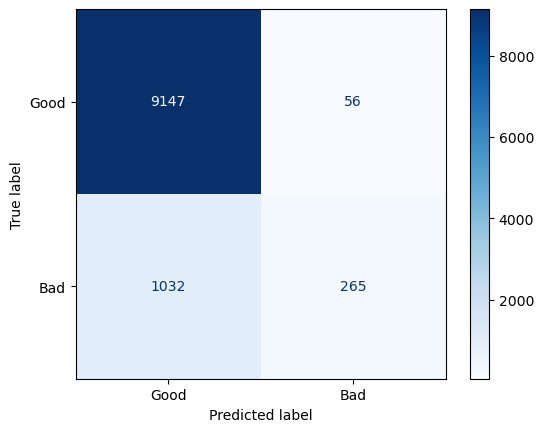

In [30]:
# ================================
# 📦 Imports
# ================================
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ================================
# 🧾 Feature-Liste
# ================================
features = features_catalog['all_in']

# Nur existierende Features
valid_features = [col for col in features if col in X_train.columns]

# ================================
# 🔍 Feature-Typen bestimmen
# ================================
numeric_features = X_train[valid_features].select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X_train[valid_features].select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()

print(f"🔢 Numerische Features: {len(numeric_features)}")
print(f"🔤 Kategorische Features: {len(categorical_features)}")

# ================================
# 🏗️ Preprocessing
# ================================
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='drop'
)

# ================================
# 🌲 Random Forest (optimiert für Recall!)
# ================================
model = RandomForestClassifier(
    n_estimators=150,          # schnell + stabil
    max_depth=10,              # verhindert Overfitting
    min_samples_leaf=10,       # glättet Entscheidungen
    max_features='sqrt',       # Standard gut
    class_weight={0:1, 1:3},   # 🔥 pusht BadBuy-Erkennung
    random_state=42,
    n_jobs=-1
)

# ================================
# 🔗 Pipeline
# ================================
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

# ================================
# 🏋️ Training
# ================================
print(f"\n🌲 Trainiere Random Forest mit {len(valid_features)} Features...")
rf_pipeline.fit(X_train[valid_features], y_train)

# ================================
# 🔮 Vorhersagen
# ================================
y_proba_rf = rf_pipeline.predict_proba(X_val[valid_features])[:, 1]

# 🔥 Threshold für Recall optimieren
threshold = 0.30
y_pred_rf = (y_proba_rf >= threshold).astype(int)

# ================================
# 📊 Tracking
# ================================
run_id = tracker.add_entry(
    model_name="random_forest_fast",
    model_obj=rf_pipeline,
    features_name="all_in",
    features_list=valid_features,
    y_true=y_val,
    y_pred=y_pred_rf,
    y_proba=y_proba_rf,
    description=f"RF fast setup | threshold={threshold} | class_weight=1:3"
)

# ================================
# 🔍 Analyse
# ================================
print(f"\n🧐 Inspektion von Run {run_id}...")
models.inspect_run_full(
    run_id,
    X_val[valid_features],
    y_val,
    tracker
)

🔢 Numerische Features: 19
🔤 Kategorische Features: 21

🌲 Trainiere Random Forest mit 41 Features...
💾 Modell-Datei erstellt: ../data/04_models/export/449_random_forest_fast.joblib
ID 449: F1=0.3569 -> ✅ ÜBER 0.30 & GESPEICHERT

🧐 Inspektion von Run 449...

════════════════════════════════════════════════════════════
🔍 ANALYSE RUN_ID: 449 | Name: random_forest_fast
════════════════════════════════════════════════════════════
⚙️  MODELL-EINSTELLUNGEN:
   • Typ:          RandomForestClassifier
   • Penalty:      N/A
   • Solver:       N/A
   • C (Regul.):   N/A
   • Class Weight: {0: 1, 1: 3}
   • Max Iter:     N/A
   • Features:     (Konnte Namen nicht auslesen)
------------------------------------------------------------
📊 PERFORMANCE REPORT:
              precision    recall  f1-score   support

    Good (0)       0.90      0.99      0.94      9203
     Bad (1)       0.83      0.20      0.33      1297

    accuracy                           0.90     10500
   macro avg       0.86      0

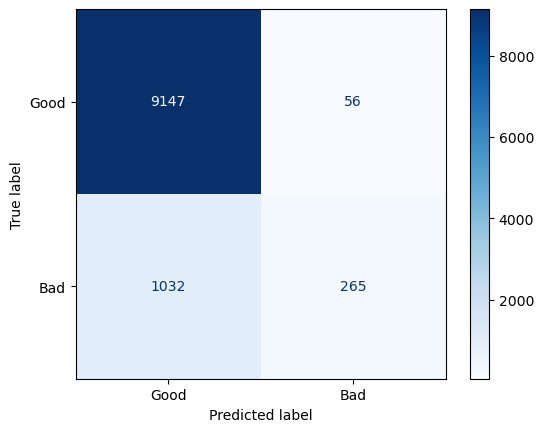

In [31]:
# ================================
# 📦 Imports
# ================================
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ================================
# 🧾 Feature-Liste
# ================================
features = features_catalog['all_in']

# Nur existierende Features
valid_features = [col for col in features if col in X_train.columns]

# ================================
# 🔍 Feature-Typen bestimmen
# ================================
numeric_features = X_train[valid_features].select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X_train[valid_features].select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()

print(f"🔢 Numerische Features: {len(numeric_features)}")
print(f"🔤 Kategorische Features: {len(categorical_features)}")

# ================================
# 🏗️ Preprocessing
# ================================
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='drop'
)

# ================================
# 🌲 Random Forest (optimiert für Recall!)
# ================================
model = RandomForestClassifier(
    n_estimators=150,          # schnell + stabil
    max_depth=10,              # verhindert Overfitting
    min_samples_leaf=10,       # glättet Entscheidungen
    max_features='sqrt',       # Standard gut
    class_weight={0:1, 1:3},   # 🔥 pusht BadBuy-Erkennung
    random_state=42,
    n_jobs=-1
)

# ================================
# 🔗 Pipeline
# ================================
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

# ================================
# 🏋️ Training
# ================================
print(f"\n🌲 Trainiere Random Forest mit {len(valid_features)} Features...")
rf_pipeline.fit(X_train[valid_features], y_train)

# ================================
# 🔮 Vorhersagen
# ================================
y_proba_rf = rf_pipeline.predict_proba(X_val[valid_features])[:, 1]

# 🔥 Threshold für Recall optimieren
threshold = 0.30
y_pred_rf = (y_proba_rf >= threshold).astype(int)

# ================================
# 📊 Tracking
# ================================
run_id = tracker.add_entry(
    model_name="random_forest_fast",
    model_obj=rf_pipeline,
    features_name="all_in",
    features_list=valid_features,
    y_true=y_val,
    y_pred=y_pred_rf,
    y_proba=y_proba_rf,
    description=f"RF fast setup | threshold={threshold} | class_weight=1:3"
)

# ================================
# 🔍 Analyse
# ================================
print(f"\n🧐 Inspektion von Run {run_id}...")
models.inspect_run_full(
    run_id,
    X_val[valid_features],
    y_val,
    tracker
)

# Bester


Winner

'''
    # Modell
    model = RandomForestClassifier(

    )
'''

        n_estimators=250,          # mehr Stabilität
        max_depth=14,              # erkennt komplexere Muster
        min_samples_leaf=5,        # feinere Splits → besser für BadBuy
        max_features='sqrt',
        max_samples=0.7,           # 🔥 mehr Diversität (sehr wichtig!)
        class_weight={0:1, 1:4},   # 🔥 pusht BadBuy-Erkennung
        random_state=42,
        n_jobs=-1

🔢 Numerische Features: 8
🔤 Kategorische Features: 5

🌲 Trainiere Random Forest mit 13 Features...
💾 Modell-Datei erstellt: ../data/04_models/export/457_random_forest_all_in.joblib
ID 457: F1=0.3900 -> ✅ ÜBER 0.30 & GESPEICHERT

🧐 Inspektion von Run 457...

════════════════════════════════════════════════════════════
🔍 ANALYSE RUN_ID: 457 | Name: random_forest_all_in
════════════════════════════════════════════════════════════
⚙️  MODELL-EINSTELLUNGEN:
   • Typ:          RandomForestClassifier
   • Penalty:      N/A
   • Solver:       N/A
   • C (Regul.):   N/A
   • Class Weight: balanced
   • Max Iter:     N/A
   • Features:     (Konnte Namen nicht auslesen)
------------------------------------------------------------
📊 PERFORMANCE REPORT:
              precision    recall  f1-score   support

    Good (0)       0.93      0.84      0.88      9203
     Bad (1)       0.31      0.52      0.39      1297

    accuracy                           0.80     10500
   macro avg       0.62      0.6

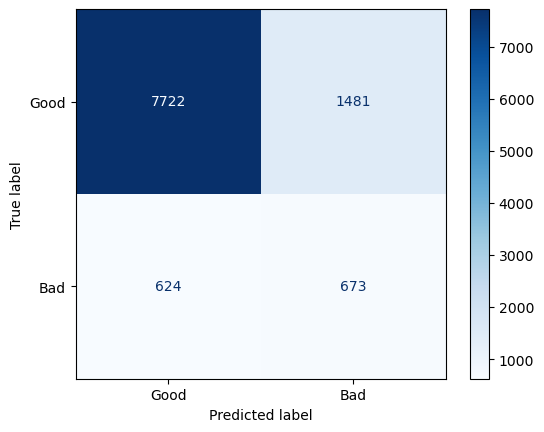

In [49]:
# ================================
# 📦 Imports
# ================================
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ================================
# 🧾 Feature-Liste
# ================================

features_all_in = [
    'PurchDate', 'Auction', 'VehYear', 'VehicleAge', 'Make', 'Model',
    'Trim', 'SubModel', 'Color', 'Transmission', 'WheelTypeID', 'WheelType',
    'VehOdo', 'Nationality', 'Size', 'TopThreeAmericanName',
    'MMRAcquisitionAuctionAveragePrice', 'MMRAcquisitionAuctionCleanPrice',
    'MMRAcquisitionRetailAveragePrice', 'MMRAcquisitonRetailCleanPrice',  # ⚠️ prüfen!
    'MMRCurrentAuctionAveragePrice', 'MMRCurrentAuctionCleanPrice',
    'MMRCurrentRetailAveragePrice', 'MMRCurrentRetailCleanPrice',
    'PRIMEUNIT', 'AUCGUART', 'BYRNO', 'VNZIP1', 'VNST', 'VehBCost',
    'IsOnlineSale', 'WarrantyCost',
    'feat_price_ratio', 'feat_price_diff', 'feat_market_trend',
    'feat_miles_per_year', 'feat_warranty_ratio', 'feat_age_group',
    'feat_odo_risk', 'feat_price_cat', 'feat_warranty_peak'
]

features_clean = [
    'VehicleAge', 
    'VehOdo',
    'VehBCost',
    'feat_price_diff',
    'feat_market_trend',
    'feat_price_ratio', 
    'feat_warranty_ratio', 
    'feat_miles_per_year',
    'feat_age_group',
    'Auction', 
    'Make', 
    'WheelType', 
    'WheelTypeID'
]

# ================================
# 🏗️ Pipeline Builder (BEST PRACTICE)
# ================================
def build_rf_pipeline(X, feature_list):
    """
    Baut eine robuste sklearn Pipeline:
    - erkennt automatisch numerische/kategorische Features
    - ignoriert fehlende Spalten sauber
    """

    # Nur Features verwenden, die wirklich existieren
    available_features = [col for col in feature_list if col in X.columns]

    if len(available_features) == 0:
        raise ValueError("❌ Keine gültigen Features im DataFrame gefunden!")

    # Feature-Typen bestimmen
    numeric_features = X[available_features].select_dtypes(
        include=['int64', 'float64']
    ).columns.tolist()

    categorical_features = X[available_features].select_dtypes(
        include=['object', 'category', 'bool']
    ).columns.tolist()

    print(f"🔢 Numerische Features: {len(numeric_features)}")
    print(f"🔤 Kategorische Features: {len(categorical_features)}")

    # Transformer
    numeric_transformer = StandardScaler()

    categorical_transformer = OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    )

    # Preprocessor
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ],
        remainder='drop'
    )

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    # Pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    return pipeline, available_features


# ================================
# 🚀 Pipeline erstellen
# ================================
rf_pipeline, valid_features = build_rf_pipeline(X_train, features_clean)

# ================================
# 🏋️ Training
# ================================
print(f"\n🌲 Trainiere Random Forest mit {len(valid_features)} Features...")
rf_pipeline.fit(X_train[valid_features], y_train)

# ================================
# 🔮 Vorhersagen
# ================================
y_pred_rf = rf_pipeline.predict(X_val[valid_features])
y_proba_rf = rf_pipeline.predict_proba(X_val[valid_features])[:, 1]

# ================================
# 📊 Tracking
# ================================
run_id = tracker.add_entry(
    model_name="random_forest_all_in",
    model_obj=rf_pipeline,
    features_name="features_clean Pipeline",
    features_list=valid_features,
    y_true=y_val,
    y_pred=y_pred_rf,
    y_proba=y_proba_rf,
    description="Random Forest (saubere Pipeline, auto feature detection)"
)

# ================================
# 🔍 Analyse
# ================================
print(f"\n🧐 Inspektion von Run {run_id}...")
models.inspect_run_full(
    run_id,
    X_val[valid_features],
    y_val,
    tracker
)

In [38]:
import pandas as pd

# Modell extrahieren
rf_model = rf_pipeline.named_steps['model']

# Feature Names nach OHE holen
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Importances
importances = rf_model.feature_importances_

# DataFrame
feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feat_imp.head(20))

                                     feature  importance
1932                  cat__WheelType_Unknown      0.1331
1928                cat__WheelTypeID_Unknown      0.1299
1926                      cat__WheelTypeID_2      0.0305
1930                   cat__WheelType_Covers      0.0281
1                            num__VehicleAge      0.0261
8           num__MMRCurrentAuctionCleanPrice      0.0245
1929                    cat__WheelType_Alloy      0.0243
16                    num__feat_market_trend      0.0237
0                               num__VehYear      0.0236
7         num__MMRCurrentAuctionAveragePrice      0.0228
11                             num__VehBCost      0.0227
1925                      cat__WheelTypeID_1      0.0223
3     num__MMRAcquisitionAuctionAveragePrice      0.0222
17                  num__feat_miles_per_year      0.0197
2213                 cat__feat_age_group_Old      0.0192
18                  num__feat_warranty_ratio      0.0191
5      num__MMRAcquisitionRetai


# zu vorsichtig

    model = RandomForestClassifier(
        n_estimators=250,          # mehr Stabilität
        max_depth=14,              # erkennt komplexere Muster
        min_samples_leaf=5,        # feinere Splits → besser für BadBuy
        max_features='sqrt',
        max_samples=0.7,           # 🔥 mehr Diversität (sehr wichtig!)
        class_weight={0:1, 1:4},   # 🔥 pusht BadBuy-Erkennung
        random_state=42,
        n_jobs=-1
    )
    
    
F1 von 0.37 → 0.41 ist in so einem Problem richtig stark.
Aber:
👉 Du hast gerade den klassischen Trade-off umgedreht
Vorher:
Recall hoch (0.62)
Precision schlecht (0.27)
Jetzt:
Precision gut (0.54)
❗ Recall schlecht (0.33)

F1 von 0.37 → 0.41 ist in so einem Problem richtig stark.
Aber:
👉 Du hast gerade den klassischen Trade-off umgedreht
Vorher:
Recall hoch (0.62)
Precision schlecht (0.27)
Jetzt:
Precision gut (0.54)
❗ Recall schlecht (0.33)



In [39]:
1932                  cat__WheelType_Unknown      0.1331
1928                cat__WheelTypeID_Unknown      0.1299
1926                      cat__WheelTypeID_2      0.0305
1930                   cat__WheelType_Covers      0.0281
1                            num__VehicleAge      0.0261
8           num__MMRCurrentAuctionCleanPrice      0.0245
1929                    cat__WheelType_Alloy      0.0243
16                    num__feat_market_trend      0.0237
0                               num__VehYear      0.0236
7         num__MMRCurrentAuctionAveragePrice      0.0228
11                             num__VehBCost      0.0227
1925                      cat__WheelTypeID_1      0.0223
3     num__MMRAcquisitionAuctionAveragePrice      0.0222
17                  num__feat_miles_per_year      0.0197
2213                 cat__feat_age_group_Old      0.0192
18                  num__feat_warranty_ratio      0.0191
5      num__MMRAcquisitionRetailAveragePrice      0.0187
2                                num__VehOdo      0.0180
6         num__MMRAcquisitonRetailCleanPrice      0.0177
4       num__MMRAcquisitionAuctionCleanPrice      0.0176


Interpretation:
👉 „Unknown WheelType“ = starker Risikoindikator
Das heißt:
fehlende Daten = schlechtes Auto
oder: billige Auktionen liefern weniger Infos
💡 Das ist ein echter Business Insight





SyntaxError: invalid syntax (4042495983.py, line 1)

In [ ]:
* viele Features helfen
* 'WheelType', 'WheelTypeID' super hilfreich